In [5]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
from ultralytics import YOLO
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Seed
import random
random.seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device       : {device}")
if device == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

import ultralytics
print(f"Ultralytics  : {ultralytics.__version__}")
print(f"PyTorch      : {torch.__version__}")

Device       : cuda
GPU          : NVIDIA GeForce RTX 5070
Ultralytics  : 8.4.23
PyTorch      : 2.10.0+cu128


## Access Dataset

In [6]:
DATA_ROOT = Path("../Bone_Fracture_Binary_Classification")

# Verify structure
for split in ["train", "val", "test"]:
    split_path = DATA_ROOT / split
    if split_path.exists():
        classes = [d.name for d in split_path.iterdir() if d.is_dir()]
        counts  = {c: len(list((split_path / c).glob("*.*"))) for c in classes}
        print(f"{split:5s}: {counts}")

train: {'fractured': 4606, 'not fractured': 4640}
val  : {'fractured': 337, 'not fractured': 492}
test : {'fractured': 238, 'not fractured': 268}


## EDA

Classes: ['fractured', 'not fractured']

train: {'fractured': 4606, 'not fractured': 4640}  (total: 9246)
val  : {'fractured': 337, 'not fractured': 492}  (total: 829)
test : {'fractured': 238, 'not fractured': 268}  (total: 506)


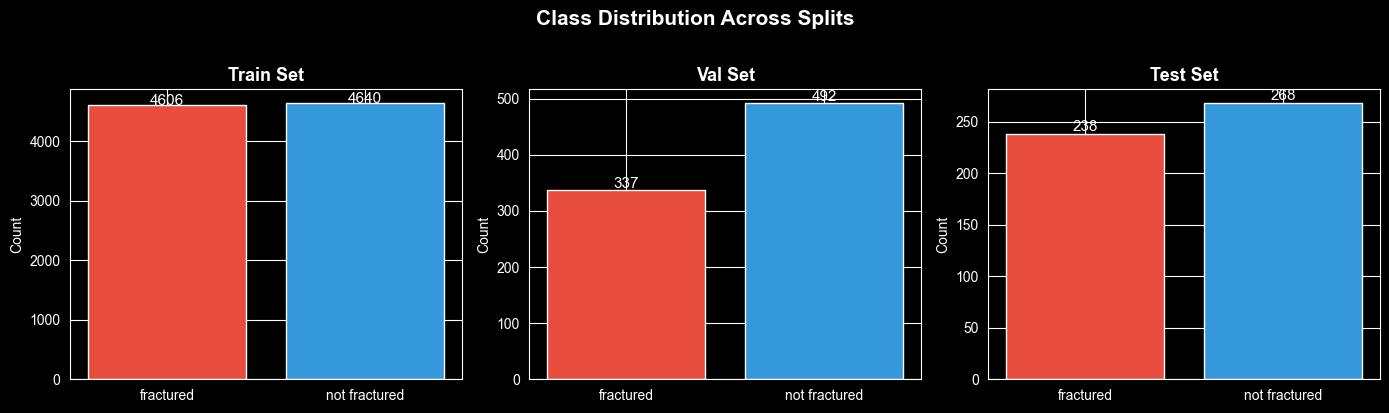

In [7]:
# Class counts per split
splits      = ["train", "val", "test"]
class_names = sorted([d.name for d in (DATA_ROOT / "train").iterdir() if d.is_dir()])

split_counts = {}
for split in splits:
    split_counts[split] = {
        cls: len(list((DATA_ROOT / split / cls).glob("*.*")))
        for cls in class_names
    }

print(f"Classes: {class_names}\n")
for split, counts in split_counts.items():
    total = sum(counts.values())
    print(f"{split:5s}: {counts}  (total: {total})")

# Bar chart
palette = ["#E74C3C", "#3498DB"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, split in zip(axes, splits):
    counts = split_counts[split]
    bars   = ax.bar(counts.keys(), counts.values(), color=palette)
    ax.set_title(f"{split.capitalize()} Set", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                str(val), ha="center", fontsize=11)

plt.suptitle("Class Distribution Across Splits", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

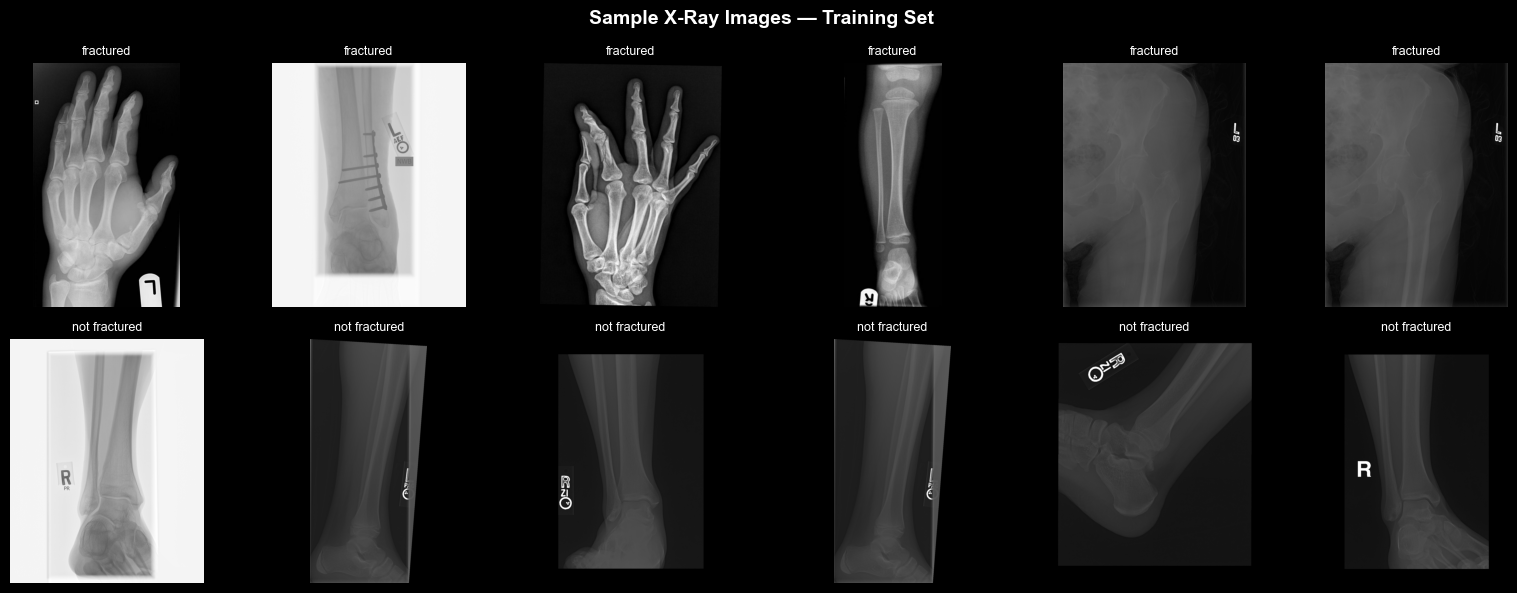

In [8]:
# Sample images grid
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Sample X-Ray Images — Training Set", fontsize=14, fontweight="bold")

for row, cls in enumerate(class_names):
    img_paths = list((DATA_ROOT / "train" / cls).glob("*.*"))[:6]
    for col, path in enumerate(img_paths):
        img = Image.open(path).convert("RGB")
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls, fontsize=9)
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()

## Select YOLO model

In [9]:
MODEL_SIZE = "yolov8m-cls"

# Load pretrained ImageNet weights
model = YOLO(f"{MODEL_SIZE}.pt")
print(f"Loaded: {MODEL_SIZE}")
print(model.info())

Loaded: yolov8m-cls
YOLOv8m-cls summary: 80 layers, 17,053,336 parameters, 0 gradients, 42.9 GFLOPs
(80, 17053336, 0, 42.9150208)


## Training

In [10]:
# Hyperparameters
EPOCHS     = 30       
IMG_SIZE   = 224
BATCH_SIZE = 32
LR         = 1e-3     # Initial learning rate
PROJECT  = "cls_runs"
RUN_NAME = "fracture_cls"

# Train
results = model.train(
    data      = str(DATA_ROOT),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    lr0       = LR,
    device    = device,
    project   = PROJECT,
    name      = RUN_NAME,
    exist_ok  = True,
    patience  = 10,       # Early stopping if val accuracy plateaus
    verbose   = True,
)

print("\nTraining complete!")
print(f"Best model saved to: {PROJECT}/{RUN_NAME}/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.10.11 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Bone_Fracture_Binary_Classification, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=

## Training Curves

In [1]:
import pandas as pd
from pathlib import Path
PROJECT  = "cls_runs"
RUN_NAME = "fracture_cls"
EPOCHS     = 30
IMG_SIZE   = 224
BATCH_SIZE = 32
LR         = 1e-3
MODEL_SIZE = "yolov8m-cls"

run_dir = Path("..") / "runs" / "classify" / PROJECT / RUN_NAME
csv_path = run_dir / "results.csv"

if csv_path.exists():
    df_log = pd.read_csv(csv_path)
    df_log.columns = df_log.columns.str.strip()   # remove whitespace from col names
    print("Columns in results.csv:", list(df_log.columns))
    print(df_log.tail())
else:
    print(f"results.csv not found at {csv_path}")

Columns in results.csv: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
    epoch     time  train/loss  metrics/accuracy_top1  metrics/accuracy_top5  \
25     26  286.194     0.00840                0.99392                      1   
26     27  296.478     0.00518                0.99514                      1   
27     28  306.766     0.00557                0.99392                      1   
28     29  316.962     0.00358                0.99149                      1   
29     30  327.091     0.00383                0.99271                      1   

    val/loss    lr/pg0    lr/pg1    lr/pg2  
25   0.03189  0.000292  0.000292  0.000292  
26   0.02064  0.000237  0.000237  0.000237  
27   0.03034  0.000182  0.000182  0.000182  
28   0.03235  0.000127  0.000127  0.000127  
29   0.02615  0.000072  0.000072  0.000072  


Mapped columns: {'train_loss': 'train/loss', 'val_loss': 'val/loss'}


C:\Users\admin\AppData\Local\Temp\ipykernel_14496\1970248981.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


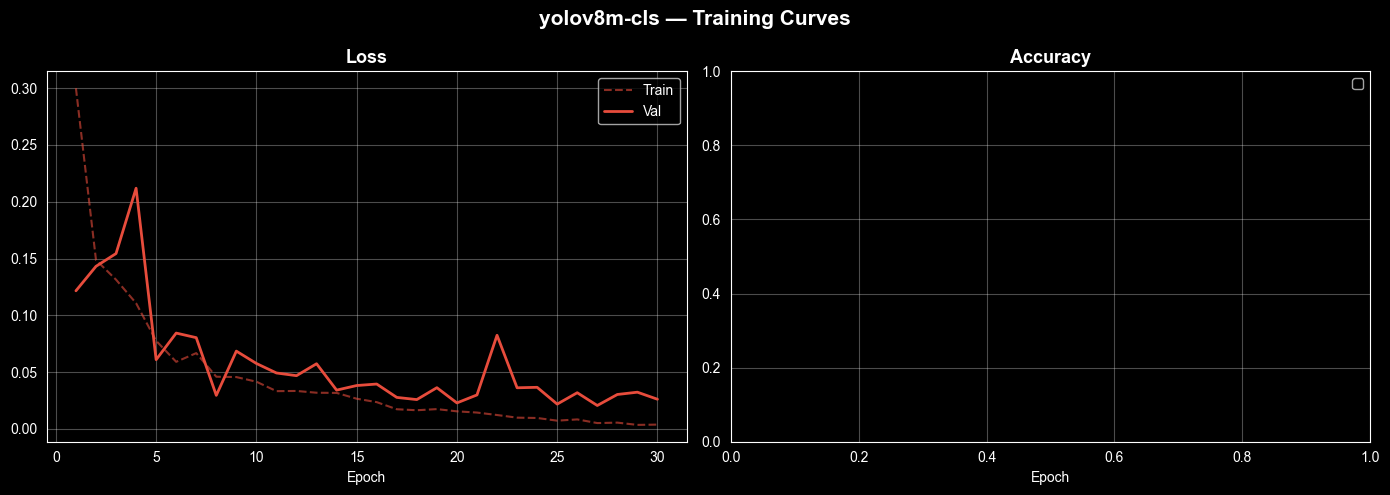

In [13]:
import matplotlib.pyplot as plt
col_map = {}
for col in df_log.columns:
    c = col.lower()
    if "train" in c and "loss" in c:    col_map["train_loss"] = col
    if "val"   in c and "loss" in c:    col_map["val_loss"]   = col
    if "train" in c and "acc" in c:     col_map["train_acc"]  = col
    if "val"   in c and "acc" in c:     col_map["val_acc"]    = col

print("Mapped columns:", col_map)

epochs = df_log["epoch"] if "epoch" in df_log.columns else range(1, len(df_log) + 1)
color  = "#E74C3C"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
if "train_loss" in col_map and "val_loss" in col_map:
    axes[0].plot(epochs, df_log[col_map["train_loss"]], "--", color=color, alpha=0.6, label="Train")
    axes[0].plot(epochs, df_log[col_map["val_loss"]],   "-",  color=color, lw=2,     label="Val")
axes[0].set_title("Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
if "train_acc" in col_map and "val_acc" in col_map:
    axes[1].plot(epochs, df_log[col_map["train_acc"]], "--", color=color, alpha=0.6, label="Train")
    axes[1].plot(epochs, df_log[col_map["val_acc"]],   "-",  color=color, lw=2,     label="Val")

    best_idx   = df_log[col_map["val_acc"]].idxmax()
    best_epoch = df_log.loc[best_idx, "epoch"] if "epoch" in df_log.columns else best_idx + 1
    best_acc   = df_log[col_map["val_acc"]].max()
    axes[1].axvline(best_epoch, color="gray", linestyle=":", alpha=0.8)
    axes[1].annotate(
        f"Best: {best_acc:.3f}\n(epoch {int(best_epoch)})",
        xy=(best_epoch, best_acc),
        xytext=(best_epoch + 1, best_acc - 0.05),
        arrowprops=dict(arrowstyle="->", color="gray"),
        fontsize=9, color="gray"
    )

axes[1].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"{MODEL_SIZE} — Training Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

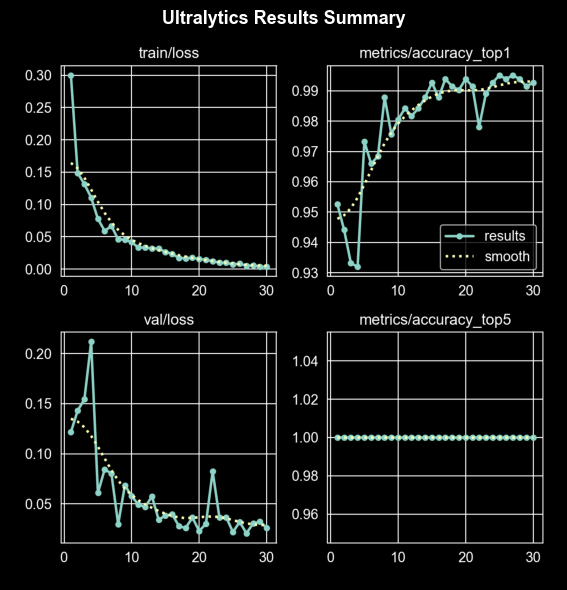

In [15]:
# Display results.png
import matplotlib.image as mpimg
results_png = run_dir / "results.png"
if results_png.exists():
    img = mpimg.imread(results_png)
    plt.figure(figsize=(14, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Ultralytics Results Summary", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("results.png not found — check run directory")

## Evaluate on test

In [2]:
from ultralytics import YOLO
from pathlib import Path
import torch
PROJECT  = "cls_runs"
RUN_NAME = "fracture_cls"
EPOCHS     = 30
IMG_SIZE   = 224
BATCH_SIZE = 32
LR         = 1e-3
MODEL_SIZE = "yolov8m-cls"
DATA_ROOT = Path("../Bone_Fracture_Binary_Classification")
run_dir = Path("..") / "runs" / "classify" / PROJECT / RUN_NAME
device = "cuda" if torch.cuda.is_available() else "cpu"

best_weights = run_dir / "weights" / "best.pt"
best_model   = YOLO(str(best_weights))
print(f"Loaded best weights from: {best_weights}")

# Validate on the test split
test_metrics = best_model.val(
    data    = str(DATA_ROOT),
    split   = "test",
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = device,
    verbose = True,
)

print("\nTest results:")
print(test_metrics)

Loaded best weights from: ..\runs\classify\cls_runs\fracture_cls\weights\best.pt
Ultralytics 8.4.23  Python-3.10.11 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,765,218 parameters, 0 gradients, 41.6 GFLOPs
train: C:\Users\admin\Desktop\CS9553\CS9553-Project\Bone_Fracture_Binary_Classification\train... found 9246 images in 2 classes  
val: C:\Users\admin\Desktop\CS9553\CS9553-Project\Bone_Fracture_Binary_Classification\val... found 829 images in 2 classes  
test: C:\Users\admin\Desktop\CS9553\CS9553-Project\Bone_Fracture_Binary_Classification\test... found 506 images in 2 classes  
test: Fast image access  (ping: 0.00.0 ms, read: 3232.1321.9 MB/s, size: 1027.5 KB)
test: Scanning C:\Users\admin\Desktop\CS9553\CS9553-Project\Bone_Fracture_Binary_Classification\test... 500 images, 6 corrupt: 100% ━━━━━━━━━━━━ 500/500  0.0s
test: C:\Users\admin\Desktop\CS9553\CS9553-Project\Bone_Fracture_Binary_Classification\test\not fractured\IMG

## Get predictions for analysis

In [3]:
# Gather all test images with their true labels
test_dir    = DATA_ROOT / "test"
class_names = sorted([d.name for d in test_dir.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}

test_images  = []
true_labels  = []

for cls in class_names:
    for img_path in sorted((test_dir / cls).glob("*.*")):
        test_images.append(str(img_path))
        true_labels.append(class_to_idx[cls])

print(f"Total test images: {len(test_images)}")
print(f"Classes: {class_names}")

Total test images: 506
Classes: ['fractured', 'not fractured']


In [4]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # ← allows PIL to load truncated images

# Run inference in batches
all_preds  = []
all_probs  = []
INFER_BATCH = 64

for i in range(0, len(test_images), INFER_BATCH):
    batch_paths = test_images[i : i + INFER_BATCH]
    results_batch = best_model.predict(
        batch_paths,
        imgsz   = IMG_SIZE,
        device  = device,
        verbose = False,
    )
    for r in results_batch:
        probs = r.probs.data.cpu().numpy()
        all_probs.append(probs)
        all_preds.append(int(probs.argmax()))

In [5]:
import numpy as np
# Run inference in batches
all_preds  = []
all_probs  = []
INFER_BATCH = 64

for i in range(0, len(test_images), INFER_BATCH):
    batch_paths = test_images[i : i + INFER_BATCH]
    results_batch = best_model.predict(
        batch_paths,
        imgsz   = IMG_SIZE,
        device  = device,
        verbose = False,
    )
    for r in results_batch:
        probs = r.probs.data.cpu().numpy()   
        all_probs.append(probs)
        all_preds.append(int(probs.argmax()))

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
true_labels = np.array(true_labels)

# Map YOLO's internal class order to our class_names order
yolo_classes = best_model.names   
print("YOLO class mapping:", yolo_classes)

acc = (all_preds == true_labels).mean()
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

YOLO class mapping: {0: 'fractured', 1: 'not fractured'}

Test Accuracy: 0.9901 (99.01%)


In [6]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
# Full classification report
print(classification_report(true_labels, all_preds, target_names=class_names))

               precision    recall  f1-score   support

    fractured       1.00      0.98      0.99       238
not fractured       0.99      1.00      0.99       268

     accuracy                           0.99       506
    macro avg       0.99      0.99      0.99       506
 weighted avg       0.99      0.99      0.99       506



## Confusion matrix

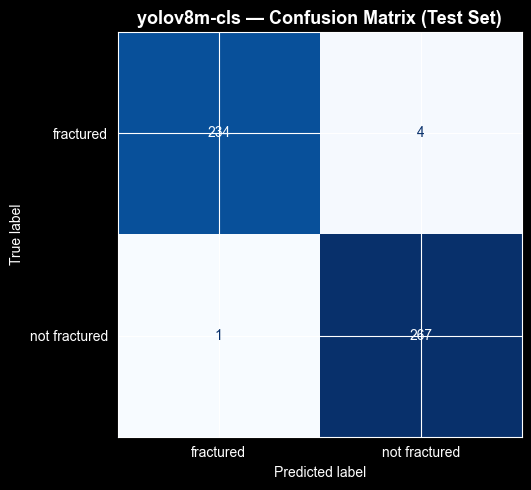

In [7]:
import matplotlib.pyplot as plt
cm   = confusion_matrix(true_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"{MODEL_SIZE} — Confusion Matrix (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## ROC Curve

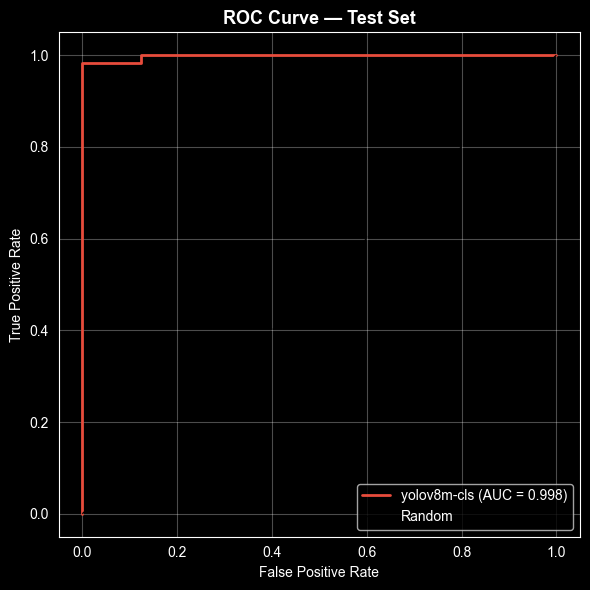

AUC: 0.9979


In [8]:
POSITIVE_CLASS = class_names.index("fractured") if "fractured" in class_names else 0

y_score       = all_probs[:, POSITIVE_CLASS]
y_true_binary = (true_labels == POSITIVE_CLASS).astype(int)
fpr, tpr, _   = roc_curve(y_true_binary, y_score)
auc           = roc_auc_score(y_true_binary, y_score)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#E74C3C", lw=2, label=f"{MODEL_SIZE} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

## View Misclassifications

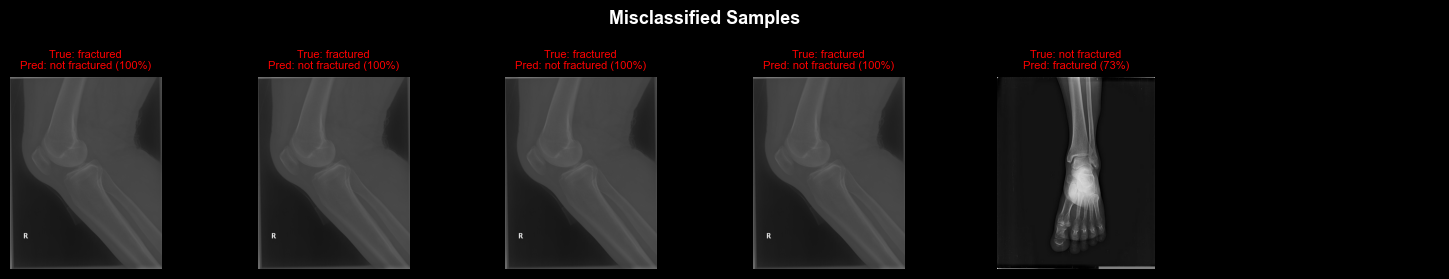

Total misclassified: 5 / 506


In [9]:
from PIL import Image

wrong_idx = np.where(all_preds != true_labels)[0][:12]

if len(wrong_idx) == 0:
    print("No misclassifications on the test set!")
else:
    cols = 6
    rows = (len(wrong_idx) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    axes = axes.flatten()

    for ax, idx in zip(axes, wrong_idx):
        img = Image.open(test_images[idx]).convert("RGB")
        ax.imshow(img)
        true_lbl = class_names[true_labels[idx]]
        pred_lbl = class_names[all_preds[idx]]
        conf     = all_probs[idx][all_preds[idx]]
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.0%})",
                     fontsize=8, color="red")
        ax.axis("off")

    for ax in axes[len(wrong_idx):]:
        ax.axis("off")

    plt.suptitle("Misclassified Samples", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Total misclassified: {len(wrong_idx)} / {len(test_images)}")

## Inference on Single Image

Image      : ..\Bone_Fracture_Binary_Classification\test\fractured\0.png
True label : fractured


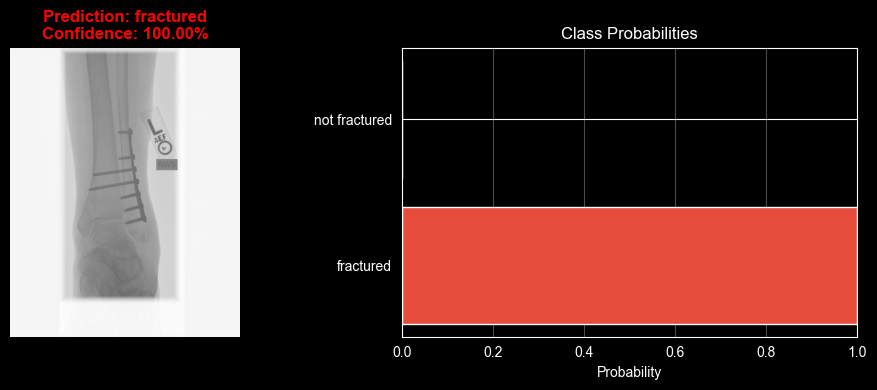

('fractured', array([          1,  1.0177e-06], dtype=float32))

In [10]:
Ddef predict_single(model, image_path, class_names=class_names):
    result = model.predict(str(image_path), imgsz=IMG_SIZE, device=device, verbose=False)[0]
    probs  = result.probs.data.cpu().numpy()
    pred   = int(probs.argmax())
    conf   = probs[pred]

    label_color = "green" if class_names[pred] == "non-fractured" else "red"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(Image.open(image_path).convert("RGB"))
    axes[0].axis("off")
    axes[0].set_title(
        f"Prediction: {class_names[pred]}\nConfidence: {conf:.2%}",
        fontsize=12, fontweight="bold", color=label_color
    )
    axes[1].barh(class_names, probs, color=["#E74C3C", "#2ECC71"])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Class Probabilities")
    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return class_names[pred], probs


# First test image
sample_path = test_images[0]
true_cls    = class_names[true_labels[0]]
print(f"Image      : {sample_path}")
print(f"True label : {true_cls}")
predict_single(best_model, sample_path)